In [1]:
# 모델 설정하기
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model='gpt-4o-mini', temperature=0.01)
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_cad7472b82', 'id': 'chatcmpl-DZvDapRYbJD2EFN5vcsKHZCV2Eiaw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd880-903b-7590-97d5-a52251a8ac46-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:
# 랭그래프-상태 설정
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.
    
    속성:
        messages (Annotated[list[str], add_messages]) : 메시지들은 "list" 타입을 가집니다.
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# State타입의 그래프 생성
graph_builder = StateGraph(State)

In [3]:
# 도구 등록하기
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import os
os.environ["USER_AGENT"] = "my-agent/1.0.0"

import bs4
from langchain_community.document_loaders import WebBaseLoader

@tool
def get_current_time(timezone:str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재 시각 {now}'
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """웹 검색을 수행하는 함수.
    Args:
        query (str): 검색어
        search_period(str) : 검색 기간(e.g., 'w' for past week (default), 'm' for past month, 'y' for past year, 'd' for past day)
        
    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(';\n')):
        print(f"{i+1}. {result}")

    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]


In [4]:
tools[0].invoke({"timezone": "Asia/Seoul", "location":"서울"})

'Asia/Seoul (서울) 현재 시각 2026-04-29 18:10:00'

In [5]:
tools[1].invoke({"query":"파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: if 조건문 손코딩 연습 - 혼자 공부하는 첫 프로그래밍, 첫 코딩 with 파이썬 03-2강 선택 구조를 파이썬으로 코딩하는 방법. • 5 лет назад • 1,9 тыс. просмотров., title: 혼자 공부하는 첫 프로그래밍 with 파이썬(feat. 한빛 미디어...) - YouTube, link: https://www.youtube.com/playlist?list=PLID7cC3lN2TGwMHut3HwvesaltOO_FlaF
2. snippet: 이 책은 생애 최초로 프로그래밍을 하려는 학생들을 대상으로 파이썬 언어와 GUI 프로그래밍을 소개한다., title: 두근두근 파이썬 (개정판) | 생능출판사, link: https://www.booksr.co.kr/product/9788970506562/
3. snippet: 일반. Unit 1. 소프트웨어 교육과 파이썬. Unit 2. 파이썬 설치하기. Unit 3. Hello, world!로 시작하기. Unit 4. 기본 문법 알아보기., title: 파이썬 코딩 도장: 23.3 반복문으로 리스트 만들기, link: https://dojang.io/mod/page/view.php?id=2293
4. snippet: 『혼자 만들면서 공부하는 파이썬』은 『혼자 공부하는 파이썬』에서 배운 지식을 실전에 적용하고자 하는 분들 위해 만들었습니다., title: 혼자 만들면서 공부하는 파이썬, link: https://hongong.hanbit.co.kr/혼자-만들면서-공부하는-파이썬/


'snippet: if 조건문 손코딩 연습 - 혼자 공부하는 첫 프로그래밍, 첫 코딩 with 파이썬 03-2강 선택 구조를 파이썬으로 코딩하는 방법. • 5 лет назад • 1,9 тыс. просмотров., title: 혼자 공부하는 첫 프로그래밍 with 파이썬(feat. 한빛 미디어...) - YouTube, link: https://www.youtube.com/playlist?list=PLID7cC3lN2TGwMHut3HwvesaltOO_FlaF;\nsnippet: 이 책은 생애 최초로 프로그래밍을 하려는 학생들을 대상으로 파이썬 언어와 GUI 프로그래밍을 소개한다., title: 두근두근 파이썬 (개정판) | 생능출판사, link: https://www.booksr.co.kr/product/9788970506562/;\nsnippet: 일반. Unit 1. 소프트웨어 교육과 파이썬. Unit 2. 파이썬 설치하기. Unit 3. Hello, world!로 시작하기. Unit 4. 기본 문법 알아보기., title: 파이썬 코딩 도장: 23.3 반복문으로 리스트 만들기, link: https://dojang.io/mod/page/view.php?id=2293;\nsnippet: 『혼자 만들면서 공부하는 파이썬』은 『혼자 공부하는 파이썬』에서 배운 지식을 실전에 적용하고자 하는 분들 위해 만들었습니다., title: 혼자 만들면서 공부하는 파이썬, link: https://hongong.hanbit.co.kr/혼자-만들면서-공부하는-파이썬/'

In [6]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x0000020851AFF560>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\n    Args:\n        query (str): 검색어\n        search_period(str) : 검색 기간(e.g., 'w' for past week (default), 'm' for past month, 'y' for past year, 'd' for past day)\n\n    Returns:\n        str: 검색 결과" args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x00000208546A9080>


In [7]:
model_with_tools = model.bind_tools(tools)

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.
    
    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
    
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리
        형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [8]:
import json
from langchain_core.messages import ToolMessage



class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}
    
    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트 가져오기
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []

        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages" : messages + outputs}
    
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [9]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)

graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

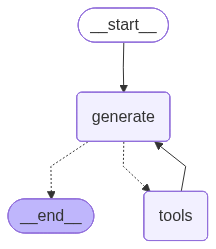

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
from langchain_core.messages import AIMessageChunk, HumanMessage


inputs = [HumanMessage(content="지금 서울 몇 시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울의 시각은 2026년 4월 29일 18시 10분입니다.

AIMessageChunk(content='현재 서울의 시각은 2026년 4월 29일 18시 10분입니다.', additional_kwargs={}, response_metadata={'model_provider': 'openai', 'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-mini-2024-07-18gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_902656a573fp_902656a573', 'service_tier': 'defaultdefault'}, id='lc_run--019dd880-a3ab-7441-b744-ef4409c5882e', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_ADrerclztXrwlCkqcVTaAH8l', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 368, 'output_tokens': 47, 'total_tokens': 415, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_ADrerclztXrwlCkqcVTaAH8l', 'index': 0, 'type': 'tool_call_chunk'}], chunk_position='last')

In [12]:
from langchain_core.messages import AIMessageChunk, SystemMessage


about = "한국 빚투 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
- 검색할 리스트를 토대로 재검색해.
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
                        
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')


-------- WEB SEARCH --------
한국 빚투 문제 최근 이슈
m
1. snippet: 국내 증시 과열 분위기 속에서 20대 청년층의 '빚투'가 1년 만에 두 배 넘게 급증한 것으로 나타났다. 일정한 소득 기반이 부족한 학생, 취업준비생 등 청년층이 신용융자를 통해 주식시장에 뛰어드는 사례가 늘면서 향후 주가 ..., title: 20대 빚투 폭탄 터지나…1년 만에 2.24배 폭증, 청년 파산 '경고등', link: https://www.joseilbo.com/news/htmls/2026/04/20260429567480.html
2. snippet: 국내 신용거래융자 잔고가 매월 최고 수준을 경신하며 35조원 규모에 육박하는 등 시장 과열이 심화되는 가운데, 제대로 된 수입이 없는 20대 청년층의 '빚투' 증가세가 폭발적으로 늘어나고 있는 것으로 확인되었다.국회 정무위원회 강민국 의원실(국민의힘)에서 금융감독원을 통해 국내 주요 10개 ..., title: 20대 '빚투' 1년 만에 2.24배 폭증, 청년 파산 우려 심각!국내 ..., link: https://www.intn.co.kr/news/articleView.html?idxno=2050477
3. snippet: [서울=뉴시스] 박주연 기자 = 신용거래융자 잔고가 연일 최고 수준을 경신하는 가운데 20대 청년층의 '빚투(빚내서투자)'가 폭발적으로 증가하고 ..., title: 증시 호황에 20대 '빚투' 폭증…1년 만에 2.24배 늘어 - 뉴시스, link: https://www.newsis.com/view/NISX20260429_0003611653
4. snippet: 한눈에 보는 오늘 : 사회 - 뉴스 : 국내 신용거래융자 잔고가 35조 원에 육박하며 시장 과열 우려가 커지는 가운데, 20대 청년층의 '빚투(빚내서 투자)' 증가세가 특히 두드러지면서 금융 건전성에 대한 경고음이 커지고 있다.국회 강민국 의원실(경남 진주시을)이 금융감독원을 통해 국내 주, title: 20대 '빚투